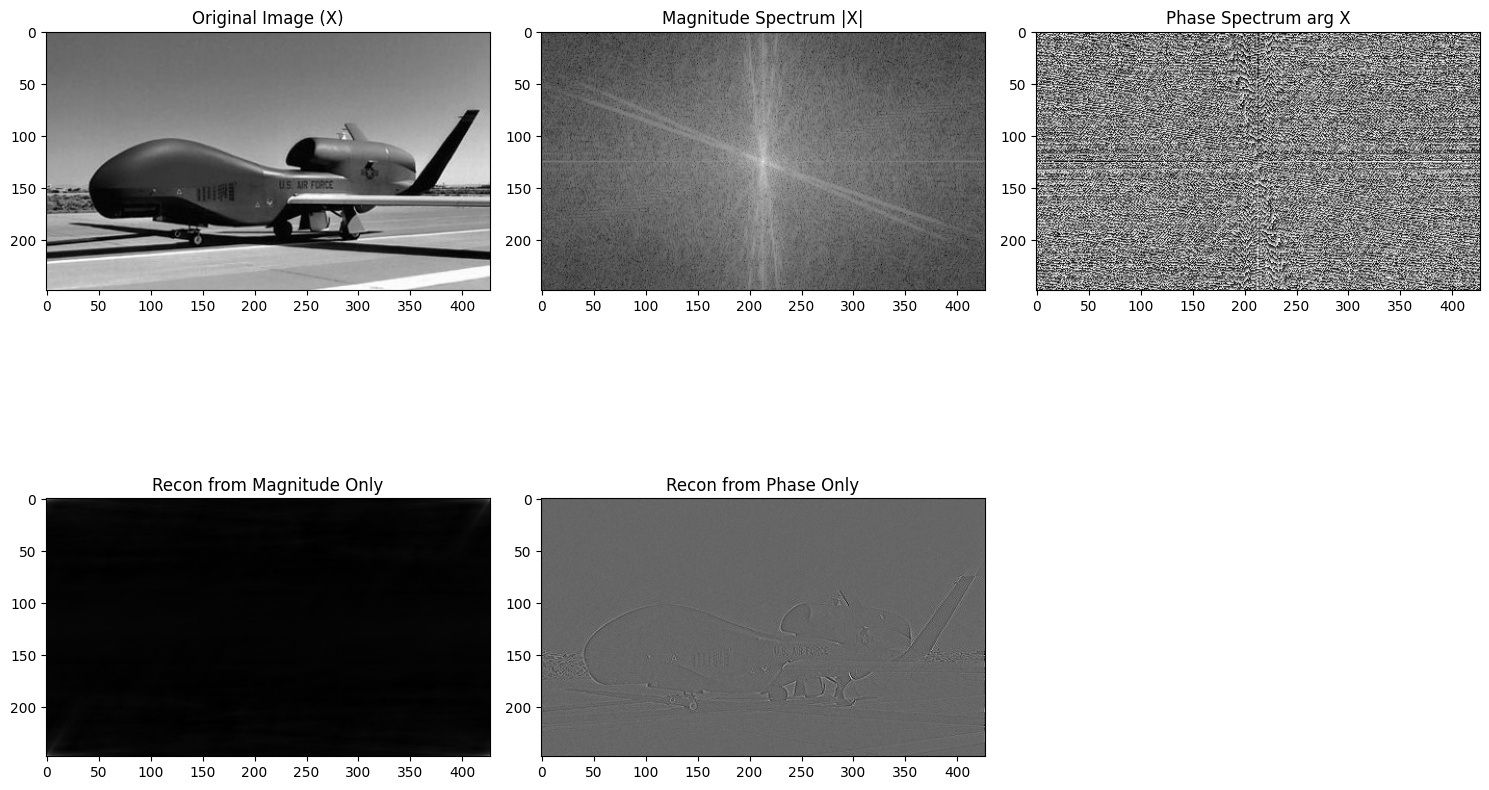

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 加载图像并转换为灰度图
img = Image.open('../imglink/drone.png').convert('L')
x = np.array(img)

# 2. 进行二维傅里叶变换
X = np.fft.fft2(x)
X_shift = np.fft.fftshift(X) # 将低频移至中心，方便可视化

# 3. 提取幅度谱和相位谱
magnitude = np.abs(X)
phase = np.angle(X)

# 4. 重建图像
# 情况 A: 仅使用幅度信息 (令相位为0)
x_mag_only = np.real(np.fft.ifft2(magnitude))

# 情况 B: 仅使用相位信息 (令幅度为常数1)
x_phase_only = np.real(np.fft.ifft2(np.exp(1j * phase)))

# 5. 可视化结果
plt.figure(figsize=(15, 10))

# 原图
plt.subplot(231), plt.imshow(x, cmap='gray'), plt.title('Original Image (X)')
# 幅度谱 (取对数以增强对比度)
plt.subplot(232), plt.imshow(np.log(1 + np.abs(X_shift)), cmap='gray'), plt.title('Magnitude Spectrum |X|')
# 相位谱
plt.subplot(233), plt.imshow(np.angle(X_shift), cmap='gray'), plt.title('Phase Spectrum arg X')

# 仅幅度重建
plt.subplot(234), plt.imshow(x_mag_only, cmap='gray'), plt.title('Recon from Magnitude Only')
# 仅相位重建
plt.subplot(235), plt.imshow(x_phase_only, cmap='gray'), plt.title('Recon from Phase Only')

plt.tight_layout()
plt.show()